In [23]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('/content/WHR2023.csv')

# Define the columns we are interested in and their new names
# The original CSV does not contain a column named 'Regional indicator'.
# Please review the available columns printed below and specify the correct column name for 'Region' if it exists.
selected_columns_map = {
    'Country name': 'Country',
    'Regional indicator': 'Region', # This column name caused a KeyError.
    'Ladder score': 'Happiness_Score',
    'Logged GDP per capita': 'GDP',
    'Social support': 'Social_Support',
    'Healthy life expectancy': 'Life_Expectancy',
    'Freedom to make life choices': 'Freedom',
    'Generosity': 'Generosity',
    'Perceptions of corruption': 'Corruption'
}

# Get the actual columns of the DataFrame
df_columns = df.columns.tolist()
print("Available columns after loading CSV:")
print(df_columns)

# Filter the selected_columns_map to only include keys that exist in the DataFrame
valid_selected_columns_map = {
    original_col: new_col
    for original_col, new_col in selected_columns_map.items()
    if original_col in df_columns
}

# Select the columns and rename them
df = df[list(valid_selected_columns_map.keys())].rename(columns=valid_selected_columns_map)


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())

import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
# Check if 'Region' column was successfully created
if 'Region' in df.columns:
    print("Regions in dataset:")
    print(df['Region'].value_counts())
else:
    print("\n'Region' column not found in the dataset. Please specify the correct column for 'Region' if available.")

print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())

# Adjust the 'Bottom 10 countries' print statement if 'Region' is not available
if 'Region' in df.columns:
    print("\nBottom 10 countries:")
    print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])
else:
    print("\nBottom 10 countries (Region column not available):")
    print(df.nsmallest(10, 'Happiness_Score')[['Country','Happiness_Score']])

Available columns after loading CSV:
['Country name', 'Ladder score', 'Standard error of ladder score', 'upperwhisker', 'lowerwhisker', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Ladder score in Dystopia', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
Dataset: 137 countries, 8 columns
       Country  Happiness_Score     GDP  Social_Support  Life_Expectancy  \
0      Finland            7.804  10.792           0.969           71.150   
1      Denmark            7.586  10.962           0.954           71.250   
2      Iceland            7.530  10.896           0.983           72.050   
3       Israel            7.473  10.639           0.943           72.697   
4  Netherlands            7.

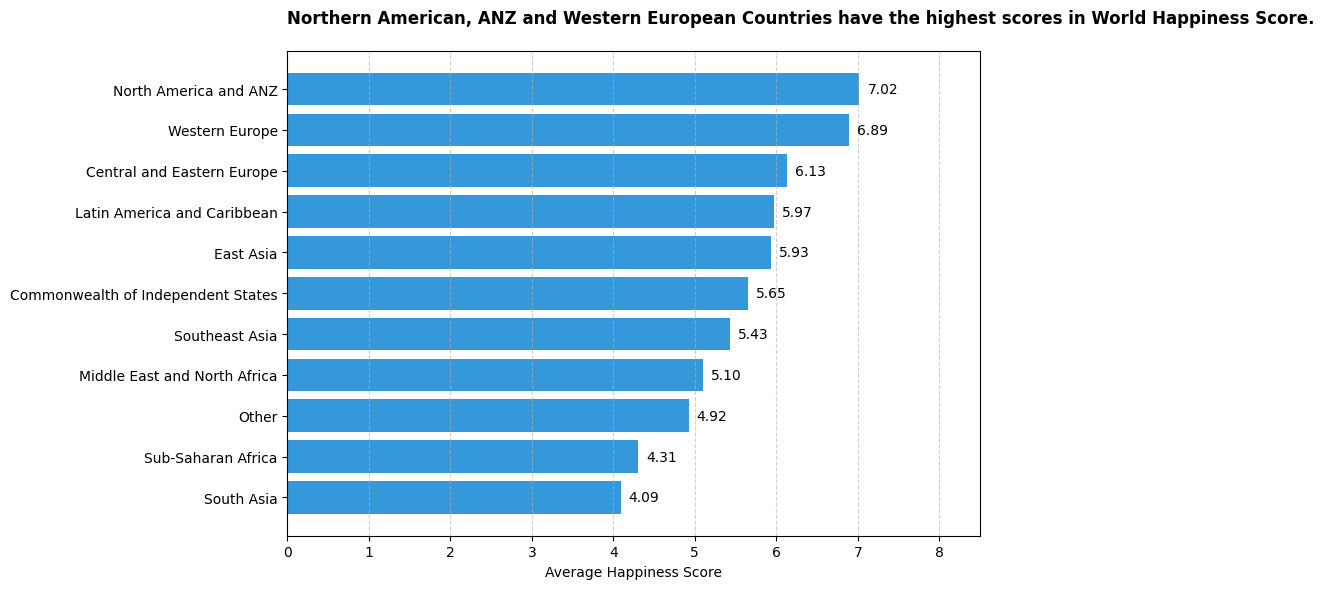

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('WHR2023.csv')

region_mapping = {
    'Finland': 'Western Europe', 'Denmark': 'Western Europe', 'Iceland': 'Western Europe', 'Israel': 'Middle East and North Africa',
    'Netherlands': 'Western Europe', 'Sweden': 'Western Europe', 'Norway': 'Western Europe', 'Switzerland': 'Western Europe',
    'Luxembourg': 'Western Europe', 'New Zealand': 'North America and ANZ', 'Austria': 'Western Europe', 'Australia': 'North America and ANZ',
    'Canada': 'North America and ANZ', 'Ireland': 'Western Europe', 'United States': 'North America and ANZ', 'Germany': 'Western Europe',
    'Belgium': 'Western Europe', 'Czechia': 'Central and Eastern Europe', 'United Kingdom': 'Western Europe', 'Lithuania': 'Central and Eastern Europe',
    'France': 'Western Europe', 'Slovenia': 'Central and Eastern Europe', 'Costa Rica': 'Latin America and Caribbean', 'Romania': 'Central and Eastern Europe',
    'Singapore': 'Southeast Asia', 'United Arab Emirates': 'Middle East and North Africa', 'Taiwan Province of China': 'East Asia', 'Uruguay': 'Latin America and Caribbean',
    'Slovakia': 'Central and Eastern Europe', 'Saudi Arabia': 'Middle East and North Africa', 'Estonia': 'Central and Eastern Europe', 'Spain': 'Western Europe',
    'Italy': 'Western Europe', 'Kosovo': 'Central and Eastern Europe', 'Chile': 'Latin America and Caribbean', 'Mexico': 'Latin America and Caribbean',
    'Malta': 'Western Europe', 'Panama': 'Latin America and Caribbean', 'Poland': 'Central and Eastern Europe', 'Nicaragua': 'Latin America and Caribbean',
    'Latvia': 'Central and Eastern Europe', 'Bahrain': 'Middle East and North Africa', 'Guatemala': 'Latin America and Caribbean', 'Kazakhstan': 'Commonwealth of Independent States',
    'Serbia': 'Central and Eastern Europe', 'Cyprus': 'Western Europe', 'Japan': 'East Asia', 'Croatia': 'Central and Eastern Europe',
    'Brazil': 'Latin America and Caribbean', 'Hungary': 'Central and Eastern Europe', 'Argentina': 'Latin America and Caribbean', 'Jamaica': 'Latin America and Caribbean',
    'Moldova': 'Commonwealth of Independent States', 'South Korea': 'East Asia', 'Mauritius': 'Sub-Saharan Africa', 'Thailand': 'Southeast Asia',
    'Mongolia': 'East Asia', 'Kyrgyzstan': 'Commonwealth of Independent States', 'China': 'East Asia', 'Vietnam': 'Southeast Asia',
    'Paraguay': 'Latin America and Caribbean', 'Montenegro': 'Central and Eastern Europe', 'Guyana': 'Latin America and Caribbean', 'Portugal': 'Western Europe',
    'Hong Kong S.A.R. of China': 'East Asia', 'Colombia': 'Latin America and Caribbean', 'Greece': 'Western Europe', 'Dominican Republic': 'Latin America and Caribbean',
    'Malaysia': 'Southeast Asia', 'Honduras': 'Latin America and Caribbean', 'Ecuador': 'Latin America and Caribbean', 'Peru': 'Latin America and Caribbean',
    'Bosnia and Herzegovina': 'Central and Eastern Europe', 'Bulgaria': 'Central and Eastern Europe', 'Philippines': 'Southeast Asia',
    'Uzbekistan': 'Commonwealth of Independent States', 'Azerbaijan': 'Commonwealth of Independent States', 'Turkiye': 'Middle East and North Africa',
    'El Salvador': 'Latin America and Caribbean', 'Bolivia': 'Latin America and Caribbean', 'Indonesia': 'Southeast Asia', 'North Macedonia': 'Central and Eastern Europe',
    'Georgia': 'Commonwealth of Independent States', 'Armenia': 'Commonwealth of Independent States', 'Tajikistan': 'Commonwealth of Independent States',
    'Nepal': 'South Asia', 'Jordan': 'Middle East and North Africa', 'Libya': 'Middle East and North Africa', 'Ivory Coast': 'Sub-Saharan Africa',
    'Congo (Brazzaville)': 'Sub-Saharan Africa', 'Albania': 'Central and Eastern Europe', 'Turkmenistan': 'Commonwealth of Independent States',
    'Gambia': 'Sub-Saharan Africa', 'Bangladesh': 'South Asia', 'Laos': 'Southeast Asia', 'South Africa': 'Sub-Saharan Africa',
    'Iraq': 'Middle East and North Africa', 'Venezuela': 'Latin America and Caribbean', 'Morocco': 'Middle East and North Africa', 'Iran': 'Middle East and North Africa',
    'Senegal': 'Sub-Saharan Africa', 'Mauritania': 'Sub-Saharan Africa', 'Burkina Faso': 'Sub-Saharan Africa', 'Namibia': 'Sub-Saharan Africa',
    'Ghana': 'Sub-Saharan Africa', 'Pakistan': 'South Asia', 'Niger': 'Sub-Saharan Africa', 'Tunisia': 'Middle East and North Africa',
    'Kenya': 'Sub-Saharan Africa', 'Sri Lanka': 'South Asia', 'Uganda': 'Sub-Saharan Africa', 'Cambodia': 'Southeast Asia',
    'Benin': 'Sub-Saharan Africa', 'Myanmar': 'Southeast Asia', 'Palestine': 'Middle East and North Africa', 'Comoros': 'Sub-Saharan Africa',
    'Liberia': 'Sub-Saharan Africa', 'Guinea': 'Sub-Saharan Africa', 'Chad': 'Sub-Saharan Africa', 'Madagascar': 'Sub-Saharan Africa',
    'Zambia': 'Sub-Saharan Africa', 'Tanzania': 'Sub-Saharan Africa', 'Ethiopia': 'Sub-Saharan Africa', 'Sierra Leone': 'Sub-Saharan Africa',
    'India': 'South Asia', 'Zimbabwe': 'Sub-Saharan Africa', 'Botswana': 'Sub-Saharan Africa', 'Malawi': 'Sub-Saharan Africa',
    'Congo (Kinshasa)': 'Sub-Saharan Africa', 'Eswatini': 'Sub-Saharan Africa', 'Rwanda': 'Sub-Saharan Africa', 'Egypt': 'Middle East and North Africa',
    'Lebanon': 'Middle East and North Africa', 'Afghanistan': 'South Asia'
}

df['Region'] = df['Country name'].map(region_mapping).fillna('Other')
df = df.rename(columns={'Ladder score': 'Happiness_Score'})

region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score')) # KURAL: Sıralama

plt.figure(figsize=(10, 6))

bars = plt.barh(region_avg['Region'], region_avg['Happiness_Score'], color='#3498db')

plt.xlim(0, 8.5)

plt.title("Northern American, ANZ and Western European Countries have the highest scores in World Happiness Score.",
          fontsize=12, fontweight='bold', pad=20, loc='left')

plt.xlabel("Average Happiness Score", fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}', va='center')

plt.tight_layout()
plt.show()

Global average: 5.54


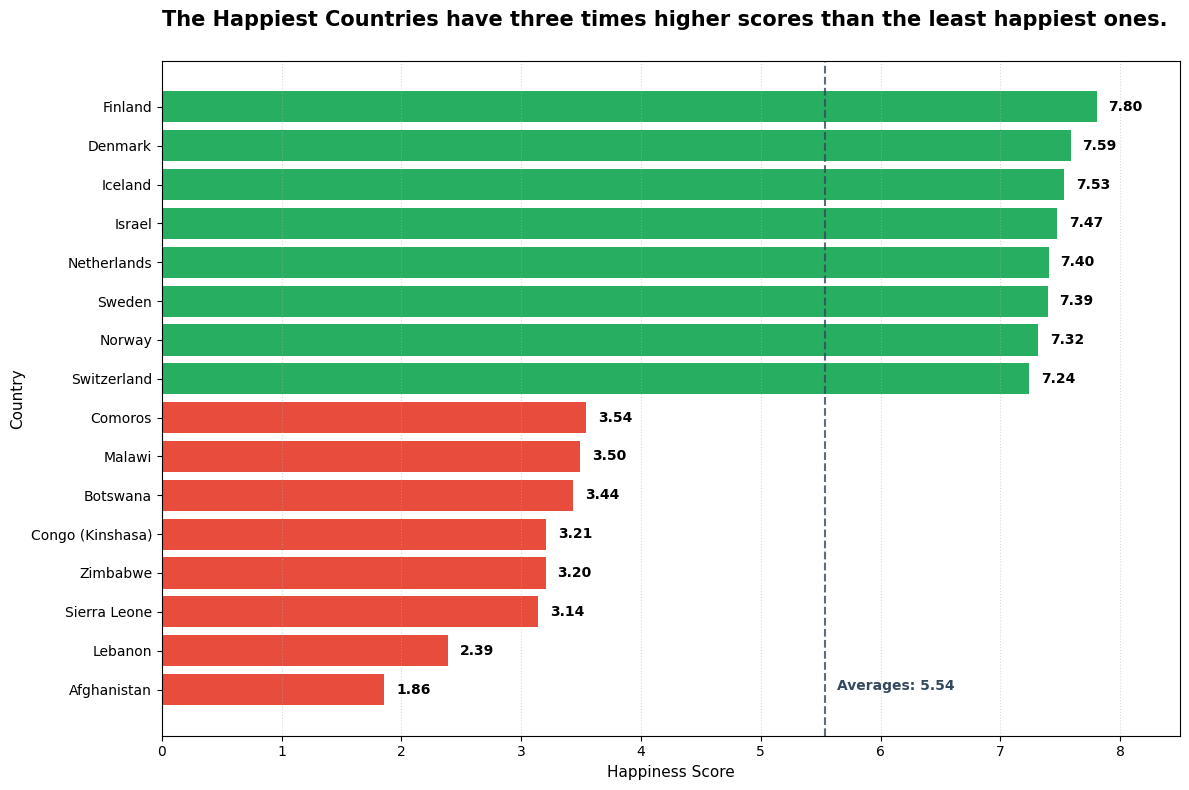

In [25]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

colors = ['#e74c3c' if g == 'Bottom 8' else '#27ae60' for g in combined['Group']]

bars = plt.barh(combined['Country name'], combined['Happiness_Score'], color=colors)

plt.xlim(0, 8.5)

plt.axvline(global_avg, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.8)
plt.text(global_avg + 0.1, 0, f'Averages: {global_avg:.2f}', color='#34495e', fontweight='bold')

plt.title("The Happiest Countries have three times higher scores than the least happiest ones.",
          fontsize=15, fontweight='bold', pad=25, loc='left')

plt.xlabel("Happiness Score", fontsize=11)
plt.ylabel("Country", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()